In [ ]:
!pip install -q datasets

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

coedit = load_dataset("grammarly/coedit")
polite_data = pd.read_csv('./polite_pairs.csv')
simplify_data = pd.read_csv('./simplify.csv')
coedit_data = coedit['train'].to_pandas()
coedit_valid = coedit['validation'].to_pandas()
coedit_data = pd.concat([coedit_data, coedit_valid])

coedit_data.drop(columns=['_id', 'task'], inplace=True)
polite_data['impolite_sentence'] = polite_data['impolite_sentence'].apply(lambda x: 'Make This Polite: ' + x)
simplify_data['complex'] = simplify_data['instruction'] + " " + simplify_data['complex']
simplify_data.drop(columns=['instruction'], inplace=True)

polite_data.rename(columns={'impolite_sentence': 'src', 'polite_sentence': 'tgt'}, inplace=True)
simplify_data.rename(columns={'complex': 'src', 'simple': 'tgt'}, inplace=True)

pd.set_option('display.max_colwidth', None)
display(coedit_data.head())
display(polite_data.head())
display(simplify_data.head())


master_df = pd.concat([coedit_data, polite_data, simplify_data], ignore_index=True)
master_df.dropna(inplace=True)
master_df.drop_duplicates(inplace=True)
# Shuffling the dataset for randomness :D (Though, ig it's unnecessary)
master_df = master_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total Data size: {len(master_df)}")

# 80% for Training, 20% for Val/Test
train_df, temp_df = train_test_split(master_df, test_size=0.2, random_state=42)
# Validation (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

final_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

final_dataset = final_dataset.remove_columns(["__index_level_0__"])
print(final_dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/19.7M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/69071 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1712 [00:00<?, ? examples/s]

,src,tgt
0,"Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.","For example, countries with a lot of deserts can transform their desert to increase their habitable land and use irrigation to provide clean water to the desert."
1,"Improve the grammaticality: As the number of people grows, the need of habitable environment is unquestionably essential.","As the number of people grows, the need for a habitable environment is unquestionably increasing."
2,"Improve the grammaticality of this sentence: Besides some technologically determinists that allow the development of biometric identification, this technology is also shaped by three social factors, namely, the desire of the society for safety, convenience and economy.","Besides some technological determinists that allow the development of biometric identification, this technology is also shaped by three social factors, namely, the desire of society for safety, convenience, and economy."
3,Remove all grammatical errors from this text: Safety is one of the crucial problems that many countries and companies concern.,Safety is one of the crucial problems that many countries and companies are concerned about.
4,"Fix grammaticality in this sentence: On one hand more and more virus and hack can access personal computers, so the secret data and documents may be stolen.","On the one hand, more and more viruses and hackers can access personal computers, so secret data and documents may be stolen."


,src,tgt
0,Make This Polite: Give me that book.,Could you please hand me that book?
1,Make This Polite: Give me that book.,Would you mind passing that book to me?
2,Make This Polite: Give me that book.,I'd appreciate it if you could give me that book.
3,Make This Polite: Give me that book.,"Excuse me, may I have that book, please?"
4,Make This Polite: Give me that book.,"If it's not too much trouble, could I trouble you for that book?"


,src,tgt
0,"""Simplify this employment law and arbitration agreement text"" ""The at-will employment doctrine allows either the employer or the employee to terminate the employment relationship at any time, for any reason, or for no reason at all, without liability, unless a contract or statute provides otherwise.""","""In an at-will job, either side can end the relationship anytime, for any reason or no reason, unless a law or contract says otherwise."""
1,"""Simplify this employment law and arbitration agreement text"" ""An arbitration agreement is a contract between employer and employee that requires any employment-related disputes to be resolved by a neutral arbitrator instead of through litigation in court, and such agreements are generally enforceable under the Federal Arbitration Act.""","""An arbitration agreement forces both employer and employee to settle workplace disputes outside of court, using a neutral arbitrator, and these agreements are usually legal."""
2,"""Simplify this employment law and arbitration agreement text"" ""A class action waiver in an arbitration agreement prohibits employees from bringing collective or class claims against the employer, requiring each employee to arbitrate their claims individually, which the Supreme Court upheld in Epic Systems Corp. v. Lewis.""","""A class action waiver forces each worker to bring their own arbitration case separately, not as a group; the Supreme Court said this is allowed."""
3,"""Simplify this employment law and arbitration agreement text"" ""The Fair Labor Standards Act (FLSA) establishes federal minimum wage, overtime pay, recordkeeping, and child labor standards affecting full-time and part-time workers in the private and public sectors.""","""The FLSA sets federal rules for minimum wage, overtime pay, and keeping records, and limits child labor for most workers."""
4,"""Simplify this employment law and arbitration agreement text"" ""Title VII of the Civil Rights Act of 1964 prohibits employment discrimination based on race, color, religion, sex, or national origin, and applies to employers with 15 or more employees.""","""Title VII bans workplace discrimination based on race, color, religion, sex, or national origin for companies with at least 15 workers."""


Total Data size: 96753
Train size: 77402 | Val size: 9675 | Test size: 9676
DatasetDict({
    train: Dataset({
        features: ['src', 'tgt'],
        num_rows: 77402
    })
    validation: Dataset({
        features: ['src', 'tgt'],
        num_rows: 9675
    })
    test: Dataset({
        features: ['src', 'tgt'],
        num_rows: 9676
    })
})


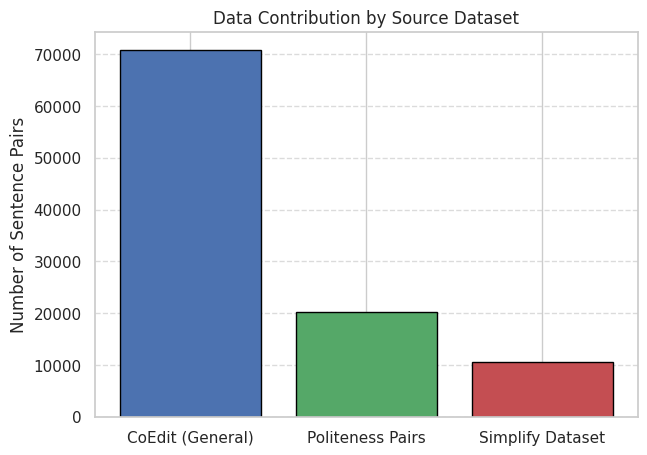

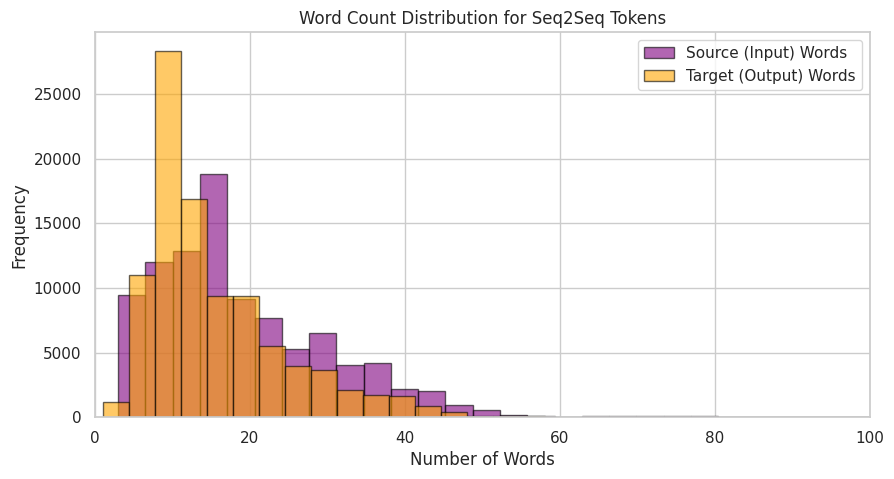


--- Sequence Length Statistics ---


,src_word_count,tgt_word_count
count,96753.000000,96753.000000
mean,19.578835,15.713880
std,11.988720,9.556172
min,3.000000,1.000000
25%,11.000000,9.000000
50%,16.000000,13.000000
75%,26.000000,20.000000
max,179.000000,169.000000


In [ ]:
import matplotlib.pyplot as plt

# Since, I used 3 datasets for my CoEdit Model, I am verifying how balanced it is.
# Counting how much data came from original dataframes
sizes = [len(coedit_data), len(polite_data), len(simplify_data)]
labels = ['CoEdit (General)', 'Politeness Pairs', 'Simplify Dataset']
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(7, 5))
plt.bar(labels, sizes, color=colors, edgecolor='black')
plt.title('Data Contribution by Source Dataset')
plt.ylabel('Number of Sentence Pairs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Calculating the word count for every source and target sentence
master_df['src_word_count'] = master_df['src'].apply(lambda x: len(str(x).split()))
master_df['tgt_word_count'] = master_df['tgt'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))

# Plotting both distributions on top of each other
plt.hist(master_df['src_word_count'], bins=50, alpha=0.6, label='Source (Input) Words', color='purple', edgecolor='black')
plt.hist(master_df['tgt_word_count'], bins=50, alpha=0.6, label='Target (Output) Words', color='orange', edgecolor='black')

plt.title('Word Count Distribution for Seq2Seq Tokens')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, max(master_df['src_word_count'].quantile(0.99), 100)) # Zoom to where 99% of data lives
plt.legend()
plt.show()

# Statistical Summary
print("\n--- Sequence Length Statistics ---")
display(master_df[['src_word_count', 'tgt_word_count']].describe())
master_df.drop(columns=['src_word_count', 'tgt_word_count'], inplace=True)

In [ ]:
from datasets import Dataset, interleave_datasets
import pandas as pd
import numpy as np

ds_coedit = Dataset.from_pandas(coedit_data)
ds_polite = Dataset.from_pandas(polite_data)
ds_simplify = Dataset.from_pandas(simplify_data)

# Dataset sizes
sizes = [len(ds_coedit), len(ds_polite), len(ds_simplify)]
print(f"Original Sizes: CoEdit={sizes[0]}, Polite={sizes[1]}, Simplify={sizes[2]}")

# Temperature-Scaled Probabilities
T = 2.0
scaled_sizes = [size**(1/T) for size in sizes]
total_scaled = sum(scaled_sizes)
probabilities = [s / total_scaled for s in scaled_sizes]

print("\n--- New Sampling Probabilities ---")
print(f"CoEdit:   {probabilities[0]:.1%}")
print(f"Polite:   {probabilities[1]:.1%}")
print(f"Simplify: {probabilities[2]:.1%}")

# Interleave the datasets
master_dataset = interleave_datasets(
    [ds_coedit, ds_polite, ds_simplify],
    probabilities=probabilities,
    seed=42,
    stopping_strategy="all_exhausted"
)

print(f"\nFinal Temperature-Scaled Dataset Size: {len(master_dataset)}")

Original Sizes: CoEdit=70783, Polite=20260, Simplify=10624

--- New Sampling Probabilities ---
CoEdit:   52.0%
Polite:   27.8%
Simplify: 20.2%

Final Temperature-Scaled Dataset Size: 136334


**Temperature scaling** is a technique used to balance an AI's "Task Bias" when one dataset is much larger than the others. It forces the AI to look at the smaller datasets than it normally would. It allows us to keep the big dataset without it "drowning out" the other tasks, ensuring the model becomes an expert in every category rather than just a grammar specialist.

**Reason For Using?**
Because Dataset was not balanced.

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset, DatasetDict
import difflib

engagement_data = load_dataset("imdb")
engagement_df = pd.DataFrame(engagement_data['train'][:10])

scoring_datasets = {}

clear_raw = load_dataset("casey-martin/CommonLit-Ease-of-Readability", split="train")
coedit_raw = load_dataset("grammarly/coedit", split="train")
jigsaw_raw = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge", split="train")
formality_data = coedit_raw.filter(lambda x: x['task'] == 'neutralize')
subj_raw = load_dataset("SetFit/subj", split="train")

crows_url = "https://raw.githubusercontent.com/nyu-mll/crows-pairs/master/data/crows_pairs_anonymized.csv"
crows_raw = pd.read_csv(crows_url)

gec_data = coedit_raw.filter(lambda x: x['task'] == 'gec')
go_raw = load_dataset("go_emotions", "simplified", split="train")
# Indices for: caring (7), gratitude (15), love (19), optimism (20), approval (4)
eq_indices = [4, 7, 15, 19, 20]

def clean_coedit_src(text):
    return text.split(":", 1)[-1].strip() if ":" in text else text

def calculate_safety(example):
    max_tox = max(example['toxic'], example['severe_toxic'], example['obscene'],
                  example['threat'], example['insult'], example['identity_hate'])
    return {'text': example['comment_text'], 'label': 1.0 - float(max_tox)}

def calculate_eq(example):
    eq_score = sum(1 for idx in example['labels'] if idx in eq_indices)
    return {'text': example['text'], 'label': min(float(eq_score) / 2.0, 1.0)}

def calculate_error_density(example):
    clean_src = clean_coedit_src(example['src'])
    tgt = example['tgt']
    similarity = difflib.SequenceMatcher(None, clean_src, tgt).ratio()
    error_density = 1.0 - similarity

    return {'text': clean_src, 'label': float(error_density)}

informal_df = pd.DataFrame({
    'text': [clean_coedit_src(t) for t in formality_data['src']],
    'label': [0.0] * len(formality_data)
})

formal_df = pd.DataFrame({
    'text': formality_data['tgt'],
    'label': [1.0] * len(formality_data)
})


polite_df = pd.DataFrame({
    'text': [clean_coedit_src(t) for t in polite_data['src']],
    'label': 1
})

impolite_df = pd.DataFrame({
    'text': polite_data['tgt'],
    'label': 0
})

biased_df = pd.DataFrame({
    'text': crows_raw['sent_more'],
    'label': 0.0
})

inclusive_df = pd.DataFrame({
    'text': crows_raw['sent_less'],
    'label': 1.0
})

print(clear_raw)

scoring_datasets['clarity'] = clear_raw.map(
    lambda x: {'text': x['Excerpt'], 'label': float(x['BT_easiness'])},
    remove_columns=clear_raw.column_names
)

scoring_datasets['formality'] = Dataset.from_pandas(pd.concat([informal_df, formal_df], ignore_index=True))
scoring_datasets['politeness'] = Dataset.from_pandas(pd.concat([impolite_df, polite_df], ignore_index=True))


scoring_datasets['safety'] = jigsaw_raw.map(calculate_safety, remove_columns=jigsaw_raw.column_names)


scoring_datasets['subjectivity'] = subj_raw.map(
    lambda x: {'text': x['text'], 'label': float(x['label'])},
    remove_columns=subj_raw.column_names
)

scoring_datasets['eq'] = go_raw.map(calculate_eq, remove_columns=go_raw.column_names)

crows_combined = pd.concat([biased_df, inclusive_df], ignore_index=True)

scoring_datasets['inclusivity'] = Dataset.from_pandas(crows_combined)
scoring_datasets['gec_density'] = gec_data.map(calculate_error_density, remove_columns=gec_data.column_names)



Filter:   0%|          | 0/69071 [00:00<?, ? examples/s]

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['ID', 'Author', 'Title', 'Anthology', 'URL', 'Pub Year', 'Categ', 'Sub Cat', 'Lexile Band', 'Location', 'License', 'MPAA Max', 'MPAA #Max', 'MPAA# Avg', 'Excerpt', 'Google WC', 'Sentence Count', 'Paragraphs', 'BT_easiness', 's.e.', 'Flesch-Reading-Ease', 'Flesch-Kincaid-Grade-Level', 'Automated Readability Index', 'SMOG Readability', 'New Dale-Chall Readability Formula', 'CAREC', 'CAREC_M', 'CML2RI', '__index_level_0__'],
    num_rows: 3543
})


/tmp/ipykernel_1863/291133619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[i], palette='viridis')
/tmp/ipykernel_1863/291133619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[i], palette='viridis')
/tmp/ipykernel_1863/291133619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[i], palette='viridis')
/tmp/ipykernel_1863/291133619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

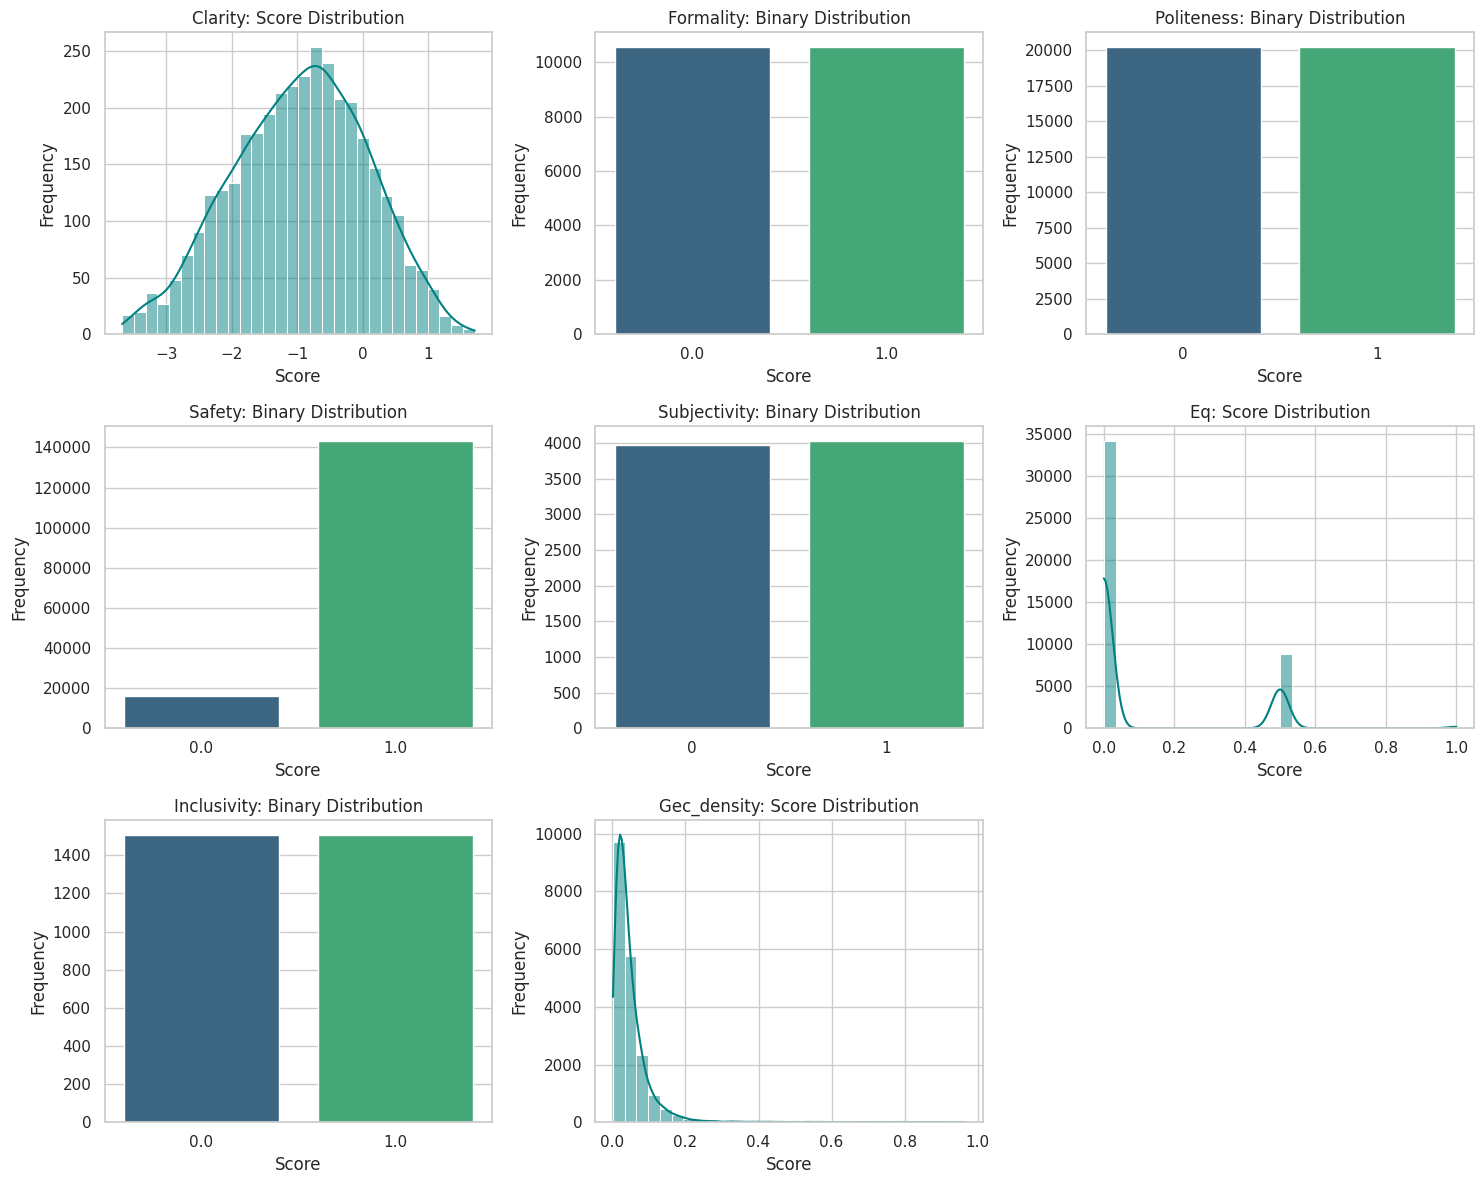


--- Scoring Dataset Summary ---


,Metric,Total Rows,Mean Score,Min,Max
0,clarity,3543,-0.959754,-3.676268,1.711390
1,formality,21140,0.500000,0.000000,1.000000
2,politeness,40520,0.500000,0.000000,1.000000
3,safety,159571,0.898321,0.000000,1.000000
4,subjectivity,8000,0.504125,0.000000,1.000000
5,eq,43410,0.109813,0.000000,1.000000
6,inclusivity,3016,0.500000,0.000000,1.000000
7,gec_density,19823,0.050033,0.001447,0.966825


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

fig, axes = plt.subplots(3, 3)
axes = axes.flatten()

dataset_keys = list(scoring_datasets.keys())

for i, key in enumerate(dataset_keys):
    df = scoring_datasets[key].to_pandas()

    # Deciding plot type based on unique values
    unique_vals = df['label'].nunique()

    if unique_vals <= 2:
        # Binary Classification
        sns.countplot(data=df, x='label', ax=axes[i], palette='viridis')
        axes[i].set_title(f'{key.capitalize()}: Binary Distribution')
    else:
        # Regression/Continuous
        sns.histplot(df['label'], bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'{key.capitalize()}: Score Distribution')

    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')

# Hiding the 9th subplot
axes[8].axis('off')

plt.tight_layout()
plt.show()

print("\n--- Scoring Dataset Summary ---")
summary_data = []
for key in scoring_datasets:
    ds = scoring_datasets[key]
    summary_data.append({
        "Metric": key,
        "Total Rows": len(ds),
        "Mean Score": np.mean(ds['label']),
        "Min": np.min(ds['label']),
        "Max": np.max(ds['label'])
    })

display(pd.DataFrame(summary_data))

In [ ]:
print(set(coedit_raw['task']))

{'paraphrase', 'clarity', 'simplification', 'gec', 'coherence', 'neutralize'}


In [4]:
import tarfile
import os


bea_gz_path = '/content/wi+locness_v2.1.bea19.tar.gz'
bea_extract_dir = '/content/bea2019_extracted'
os.makedirs(bea_extract_dir, exist_ok=True)

print(f"Extracting {bea_gz_path}...")
with tarfile.open(bea_gz_path, 'r:gz') as tar:
    tar.extractall(path=bea_extract_dir)
print(f"Extracted BEA-2019 to {bea_extract_dir}/")
print("Contents of BEA-2019 extracted directory:")
print(os.listdir(bea_extract_dir))


conll_gz_path = '/content/conll14st-test-data.tar.gz'
conll_extract_dir = '/content/conll2014_extracted'
os.makedirs(conll_extract_dir, exist_ok=True)

print(f"\nExtracting {conll_gz_path}...")
with tarfile.open(conll_gz_path, 'r:gz') as tar:
    tar.extractall(path=conll_extract_dir)
print(f"Extracted CoNLL-2014 to {conll_extract_dir}/")
print("Contents of CoNLL-2014 extracted directory:")
print(os.listdir(conll_extract_dir))

Extracting /content/wi+locness_v2.1.bea19.tar.gz...
Extracted BEA-2019 to /content/bea2019_extracted/
Contents of BEA-2019 extracted directory:
['wi+locness']

Extracting /content/conll14st-test-data.tar.gz...
Extracted CoNLL-2014 to /content/conll2014_extracted/
Contents of CoNLL-2014 extracted directory:
['conll14st-test-data']


/tmp/ipykernel_1843/1097451209.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=bea_extract_dir)
/tmp/ipykernel_1843/1097451209.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=conll_extract_dir)


In [5]:
!git clone https://github.com/lorafei/Explainable_GEC.git
print("Cloned the Explainable_GEC repository.")

Cloning into 'Explainable_GEC'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 65 (delta 14), reused 65 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 5.44 MiB | 6.58 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Cloned the Explainable_GEC repository.


--- 1. Peeking at Raw M2 File: B.train.gold.bea19.m2 ---

S I would like to make a reservation for the next month , from 24th may till 28th ( 4 nights , Double room ) but I have doubts about booking policy .
A 8 9|||U:DET||||||REQUIRED|||-NONE-|||0
A 15 16|||R:PREP|||to|||REQUIRED|||-NONE-|||0
A 27 28|||R:NOUN|||questions|||REQUIRED|||-NONE-|||0
A 29 29|||M:DET|||your|||REQUIRED|||-NONE-|||0

S I mean , after reading the terms and deposit policy , I understand I must pay the first night at the booking time and the rest of the stay it would be paid upon arrival to the front desk .
A 16 16|||M:PREP|||for|||REQUIRED|||-NONE-|||0
A 21 23|||R:OTHER|||time of booking|||REQUIRED|||-NONE-|||0
A 29 30|||U:PRON||||||REQUIRED|||-NONE-|||0
A 30 31|||R:VERB:TENSE|||should|||REQUIRED|||-NONE-|||0
A 35 36|||R:PREP|||at|||REQUIRED|||-NONE-|||0

S Plus , in case I cancelled the reservation 48 hrs before arrival it would charged the 5% of the full stay .
A 2 4|||R:OTHER|||if|||REQUIRED|||-NONE-|||0


--

,source_text,error_types,error_count
0,"I would like to make a reservation for the next month , from 24th may till 28th ( 4 nights , Double room ) but I have doubts about booking policy .","[U:DET, R:PREP, R:NOUN, M:DET]",4
1,"I mean , after reading the terms and deposit policy , I understand I must pay the first night at the booking time and the rest of the stay it would be paid upon arrival to the front desk .","[M:PREP, R:OTHER, U:PRON, R:VERB:TENSE, R:PREP]",5
2,"Plus , in case I cancelled the reservation 48 hrs before arrival it would charged the 5% of the full stay .","[R:OTHER, R:VERB:TENSE, R:PRON, R:VERB:TENSE, M:VERB:TENSE, U:DET]",6
3,"I understand this part , but in case I have to cancel the reservation , how should I do it ?",[R:OTHER],1
4,"By phone , by mail or on your website .",[],0


/tmp/ipykernel_1843/2137970863.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=gec_df, x='error_count', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1843/2137970863.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_errors.values, y=top_errors.index, ax=axes[1], palette='flare')


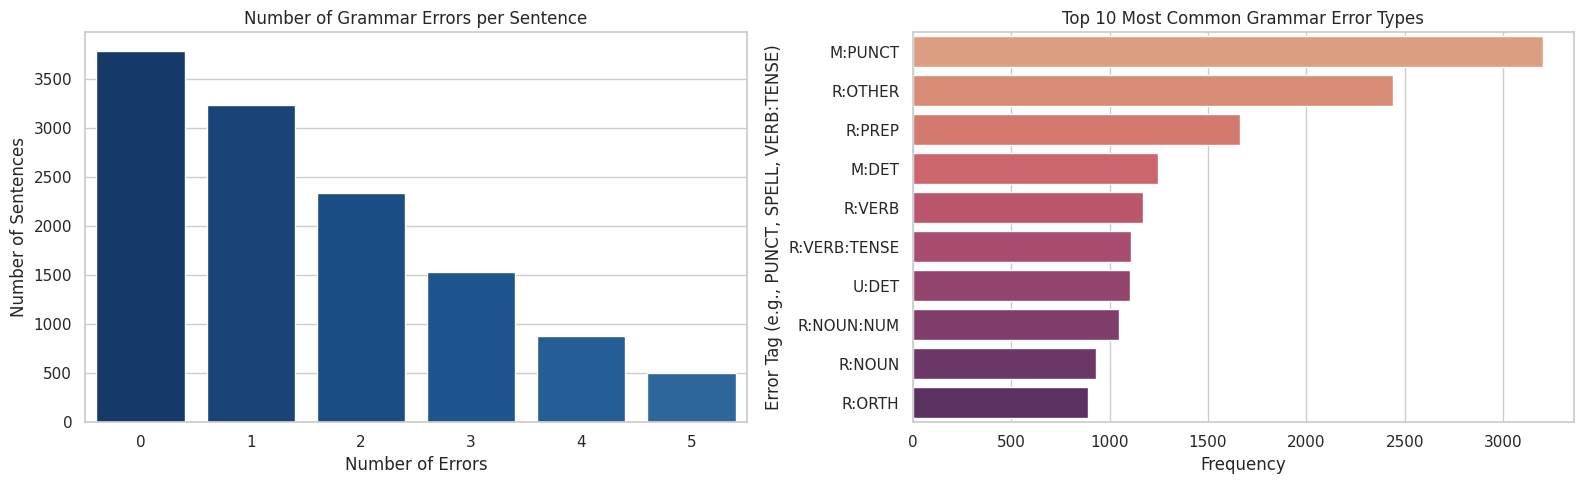

Total Sentences parsed: 13032
Total Sentences with ZERO errors (Perfect grammar): 3789
Total Sentences WITH errors: 9243


In [6]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

m2_files = glob.glob('/content/bea2019_extracted/**/*.m2', recursive=True)

if not m2_files:
    print("Could not find .m2 files. Let's check the CoNLL folder instead...")
    m2_files = glob.glob('/content/conll2014_extracted/**/*.m2', recursive=True)

sample_file = m2_files[0]
print(f"--- 1. Peeking at Raw M2 File: {os.path.basename(sample_file)} ---\n")

with open(sample_file, 'r', encoding='utf-8') as f:
    for i in range(15):
        print(f.readline().strip())

print("\n" + "="*50 + "\n")

print("--- 2. Parsing M2 format into a Pandas DataFrame ---")

parsed_data = []
current_sentence = ""
current_errors = []

with open(sample_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line.startswith('S '):
            if current_sentence:
                parsed_data.append({
                    'source_text': current_sentence,
                    'error_types': current_errors,
                    'error_count': len(current_errors)
                })
            current_sentence = line[2:]
            current_errors = []

        elif line.startswith('A '):
            parts = line.split('|||')
            if len(parts) > 1 and parts[1] != 'noop':
                error_tag = parts[1]
                current_errors.append(error_tag)

if current_sentence:
    parsed_data.append({'source_text': current_sentence, 'error_types': current_errors, 'error_count': len(current_errors)})

gec_df = pd.DataFrame(parsed_data)

pd.set_option('display.max_colwidth', None)
display(gec_df.head())


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=gec_df, x='error_count', ax=axes[0], palette='Blues_r')
axes[0].set_title('Number of Grammar Errors per Sentence')
axes[0].set_xlabel('Number of Errors')
axes[0].set_ylabel('Number of Sentences')
axes[0].set_xlim(-0.5, 5.5)

all_errors = gec_df.explode('error_types').dropna()
top_errors = all_errors['error_types'].value_counts().head(10)

sns.barplot(x=top_errors.values, y=top_errors.index, ax=axes[1], palette='flare')
axes[1].set_title('Top 10 Most Common Grammar Error Types')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Error Tag (e.g., PUNCT, SPELL, VERB:TENSE)')

plt.tight_layout()
plt.show()

print(f"Total Sentences parsed: {len(gec_df)}")
print(f"Total Sentences with ZERO errors: {len(gec_df[gec_df['error_count'] == 0])}")
print(f"Total Sentences WITH errors: {len(gec_df[gec_df['error_count'] > 0])}")